# Notebook 19 - Pilot Validasi Skeleton CVAT, MediaPipe, dan Label Benar/Salah per-Frame

**Tujuan notebook ini** adalah menerjemahkan tiga arahan Pak Jasman ke dalam eksekusi teknis yang dapat ditunjukkan secara visual dan kuantitatif:

1. Menentukan jumlah titik sendi CVAT yang benar-benar selaras dengan kebutuhan penelitian.
2. Membuktikan bahwa titik sendi hasil MediaPipe memang dapat dikeluarkan, divisualisasikan, dan diuji kualitas skeleton-nya.
3. Menunjukkan bagaimana label **Benar / Salah** per-frame dibentuk secara matematis menggunakan aturan biomekanik, bukan sekadar opini visual.

Notebook ini memakai **satu video squat pilot** sebagai studi kasus awal dan menyimpan artefak hasil ke folder `results/cvat_pilot_notebook19/`.

## Interpretasi Teknis atas Arahan Pak Jasman

### 1. "Jumlah titik sendi yang mau dibuat, sesuaikan dengan titik-titik sendi yang diperhatikan di penelitian ini"
Makna operasionalnya adalah: anotasi manual CVAT tidak perlu asal banyak, tetapi harus mengikuti **sendi yang benar-benar dipakai dalam logika penelitian**. Untuk gerakan squat, inti validasi biomekanik saat ini bergantung pada **bahu, pinggul, lutut, dan pergelangan kaki**. Karena itu, skema anotasi yang efisien adalah:

- **Minimal untuk validator penelitian**: 8 joint inti (`left/right shoulder`, `left/right hip`, `left/right knee`, `left/right ankle`).
- **Disarankan untuk pilot CVAT manual**: 12 joint utama (`shoulder`, `elbow`, `wrist`, `hip`, `knee`, `ankle` kiri/kanan) agar tubuh atas dan bawah tetap terbaca jelas.
- **Opsional**: `nose` hanya sebagai referensi orientasi kepala, bukan inti aturan squat saat ini.

### 2. "Apakah titik-titik sendi hasil MediaPipe bisa dikeluarkan? Jika bisa, boleh diuji coba seberapa baik skeleton-nya"
Jawabannya **ya**. Pipeline proyek ini memang sudah mengekstraksi 33 landmark BlazePose per-frame. Di notebook ini, titik-titik itu akan:

- dikeluarkan menjadi tabel data,
- divisualisasikan sebagai skeleton overlay, dan
- diuji dengan dua lapis evaluasi: **audit kualitas internal** dan **pembanding eksternal ke CVAT** bila file ekspor anotasi tersedia.

### 3. "Silakan diberikan label untuk setiap frame, label benar salahnya"
Makna yang paling konsisten dengan arsitektur penelitian saat ini adalah: setiap frame diberi label **Benar / Salah** menggunakan **aturan biomekanik per-frame**, sedangkan model AttentiveSkel3D tetap merupakan **classifier level-sekuens**. Jadi, `web_app/app.py` memang sudah bergerak ke arah yang benar, tetapi notebook ini memformalkan penjelasan matematis dan visualnya secara eksplisit.

In [10]:
from __future__ import annotations

import os
import sys
import warnings
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', context='talk')

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / 'src').exists() and (candidate / 'data').exists():
            return candidate
    raise RuntimeError('Project root tidak ditemukan dari working directory notebook saat ini.')

PROJECT_ROOT = resolve_project_root()
SRC_PATH = PROJECT_ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from data.biomechanics_validator import BiomechanicalValidator
from analysis.biomechanical_validator_audit import PerFrameAnalyzer
from analysis.cvat_mediapipe_pilot import (
    CVAT_12_JOINTS,
    OPTIONAL_REFERENCE_JOINTS,
    SQUAT_RESEARCH_JOINTS,
    compare_cvat_vs_mediapipe,
    draw_pose_overlay,
    extract_mediapipe_landmarks,
    find_candidate_cvat_exports,
    flatten_landmarks,
    parse_cvat_skeleton_export,
    run_preprocess_pipeline,
    select_representative_frames,
    summarize_visibility,
)

OUTPUT_DIR = PROJECT_ROOT / 'results' / 'cvat_pilot_notebook19'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_VIDEO = PROJECT_ROOT / 'data' / 'raw' / 'Squat' / 'primer_squat_frontal_subjek01_rep1.mp4'
if not SAMPLE_VIDEO.exists():
    raise FileNotFoundError(f'Video pilot tidak ditemukan: {SAMPLE_VIDEO}')

CVAT_CANDIDATES = find_candidate_cvat_exports(PROJECT_ROOT)
CVAT_EXPORT = CVAT_CANDIDATES[0] if CVAT_CANDIDATES else None

print(f'Project root : {PROJECT_ROOT}')
print(f'Video pilot  : {SAMPLE_VIDEO.name}')
print(f'Output dir   : {OUTPUT_DIR}')
print(f'CVAT export  : {CVAT_EXPORT if CVAT_EXPORT else "BELUM DITEMUKAN"}')

Project root : D:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC
Video pilot  : primer_squat_frontal_subjek01_rep1.mp4
Output dir   : D:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC\results\cvat_pilot_notebook19
CVAT export  : D:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC\data\annotations\annotations.xml


## Point 1 - Penetapan Skema Titik Sendi yang Selaras dengan Penelitian

Bagian ini menjawab arahan pertama secara eksplisit. Prinsipnya bukan "semakin banyak titik semakin baik", melainkan **jumlah titik harus selaras dengan sendi yang dipakai oleh logika biomekanik penelitian**. Untuk squat, dua level skema yang paling defensible adalah:

- **Level validasi minimal**: cukup untuk memeriksa aturan sudut dan rasio pada validator.
- **Level anotasi manual yang pragmatis**: 12 joint utama agar anotasi tetap realistis, namun masih kaya secara visual untuk pembanding terhadap MediaPipe.

In [11]:
joint_strategy_df = pd.DataFrame(
    [
        {
            'Skema': 'Minimal validator penelitian',
            'Jumlah joint': len(SQUAT_RESEARCH_JOINTS['minimum_validator_subset']),
            'Daftar joint': ', '.join(SQUAT_RESEARCH_JOINTS['minimum_validator_subset']),
            'Alasan teknis': 'Cukup untuk menghitung knee valgus ratio, hip flexion angle, dan knee angle.',
        },
        {
            'Skema': 'Disarankan untuk pilot CVAT manual',
            'Jumlah joint': len(CVAT_12_JOINTS),
            'Daftar joint': ', '.join(CVAT_12_JOINTS),
            'Alasan teknis': 'Memberi konteks lengan dan batang tubuh, tetapi tetap efisien untuk anotasi manual.',
        },
        {
            'Skema': 'Joint referensi opsional',
            'Jumlah joint': len(OPTIONAL_REFERENCE_JOINTS),
            'Daftar joint': ', '.join(OPTIONAL_REFERENCE_JOINTS),
            'Alasan teknis': 'Berguna untuk orientasi visual kepala, bukan aturan inti squat saat ini.',
        },
    ]
)

joint_catalog_df = pd.DataFrame(
    {
        'joint_order_cvat': range(1, len(CVAT_12_JOINTS) + 1),
        'joint_name': CVAT_12_JOINTS,
    }
)

display(joint_strategy_df)
display(joint_catalog_df)
joint_catalog_df.to_csv(OUTPUT_DIR / 'point1_joint_catalog.csv', index=False)
print('Katalog joint disimpan ke:', OUTPUT_DIR / 'point1_joint_catalog.csv')

,Skema,Jumlah joint,Daftar joint,Alasan teknis
0,Minimal validator penelitian,8,"left_shoulder, right_shoulder, left_hip, right...","Cukup untuk menghitung knee valgus ratio, hip ..."
1,Disarankan untuk pilot CVAT manual,12,"left_shoulder, right_shoulder, left_elbow, rig...","Memberi konteks lengan dan batang tubuh, tetap..."
2,Joint referensi opsional,1,nose,"Berguna untuk orientasi visual kepala, bukan a..."


,joint_order_cvat,joint_name
0,1,left_shoulder
1,2,right_shoulder
2,3,left_elbow
3,4,right_elbow
4,5,left_wrist
5,6,right_wrist
6,7,left_hip
7,8,right_hip
8,9,left_knee
9,10,right_knee


Katalog joint disimpan ke: D:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC\results\cvat_pilot_notebook19\point1_joint_catalog.csv


## Point 2 - Ekspor Skeleton MediaPipe dan Audit Kualitas Skeleton

Bagian ini membuktikan dua hal sekaligus:

1. **Titik sendi MediaPipe memang bisa dikeluarkan** dalam bentuk data numerik per-frame.
2. Skeleton yang dihasilkan dapat **diaudit kualitasnya**. Pada notebook ini audit dilakukan lewat:
   - jumlah frame terdeteksi,
   - coverage landmark penting,
   - visibility rata-rata, dan
   - visualisasi skeleton overlay pada beberapa frame representatif.

Jika file ekspor CVAT tersedia, blok berikutnya juga akan melakukan **pembandingan kuantitatif manual-vs-MediaPipe**.

In [12]:
bundle = extract_mediapipe_landmarks(SAMPLE_VIDEO)
landmark_df = flatten_landmarks(bundle)
visibility_df = summarize_visibility(bundle.pose_array, CVAT_12_JOINTS)

quality_summary = pd.DataFrame(
    [
        {'Metric': 'Total original frames', 'Value': int(bundle.pose_array.shape[0])},
        {'Metric': 'Frames with detected pose', 'Value': int(bundle.detected_mask.sum())},
        {'Metric': 'Pose detection ratio', 'Value': round(float(bundle.detected_mask.mean()), 4)},
        {'Metric': 'Video FPS', 'Value': round(float(bundle.fps), 2)},
        {'Metric': 'Frame width', 'Value': int(bundle.frame_width)},
        {'Metric': 'Frame height', 'Value': int(bundle.frame_height)},
        {'Metric': 'Mean visibility on 12 CVAT joints', 'Value': round(float(visibility_df['mean_visibility'].mean()), 4)},
        {'Metric': 'Mean coverage on 12 CVAT joints', 'Value': round(float(visibility_df['coverage_ratio'].mean()), 4)},
    ]
)

display(quality_summary)
display(visibility_df)

landmark_df.to_csv(OUTPUT_DIR / 'point2_mediapipe_landmarks_long.csv', index=False)
quality_summary.to_csv(OUTPUT_DIR / 'point2_quality_summary.csv', index=False)
visibility_df.to_csv(OUTPUT_DIR / 'point2_visibility_summary.csv', index=False)

print('CSV landmarks panjang disimpan ke:', OUTPUT_DIR / 'point2_mediapipe_landmarks_long.csv')
print('Ringkasan kualitas disimpan ke :', OUTPUT_DIR / 'point2_quality_summary.csv')

,Metric,Value
0,Total original frames,99.0000
1,Frames with detected pose,99.0000
2,Pose detection ratio,1.0000
3,Video FPS,30.0000
4,Frame width,1080.0000
5,Frame height,1920.0000
6,Mean visibility on 12 CVAT joints,0.9751
7,Mean coverage on 12 CVAT joints,1.0000


,joint_name,mean_visibility,min_visibility,coverage_ratio
6,left_hip,0.999944,0.999836,1.0
7,right_hip,0.999936,0.999804,1.0
0,left_shoulder,0.999913,0.999883,1.0
1,right_shoulder,0.999840,0.999772,1.0
8,left_knee,0.988371,0.981501,1.0
9,right_knee,0.986313,0.975747,1.0
5,right_wrist,0.979192,0.957264,1.0
11,right_ankle,0.975638,0.954852,1.0
4,left_wrist,0.974742,0.962022,1.0
10,left_ankle,0.966385,0.935975,1.0


CSV landmarks panjang disimpan ke: D:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC\results\cvat_pilot_notebook19\point2_mediapipe_landmarks_long.csv
Ringkasan kualitas disimpan ke : D:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC\results\cvat_pilot_notebook19\point2_quality_summary.csv


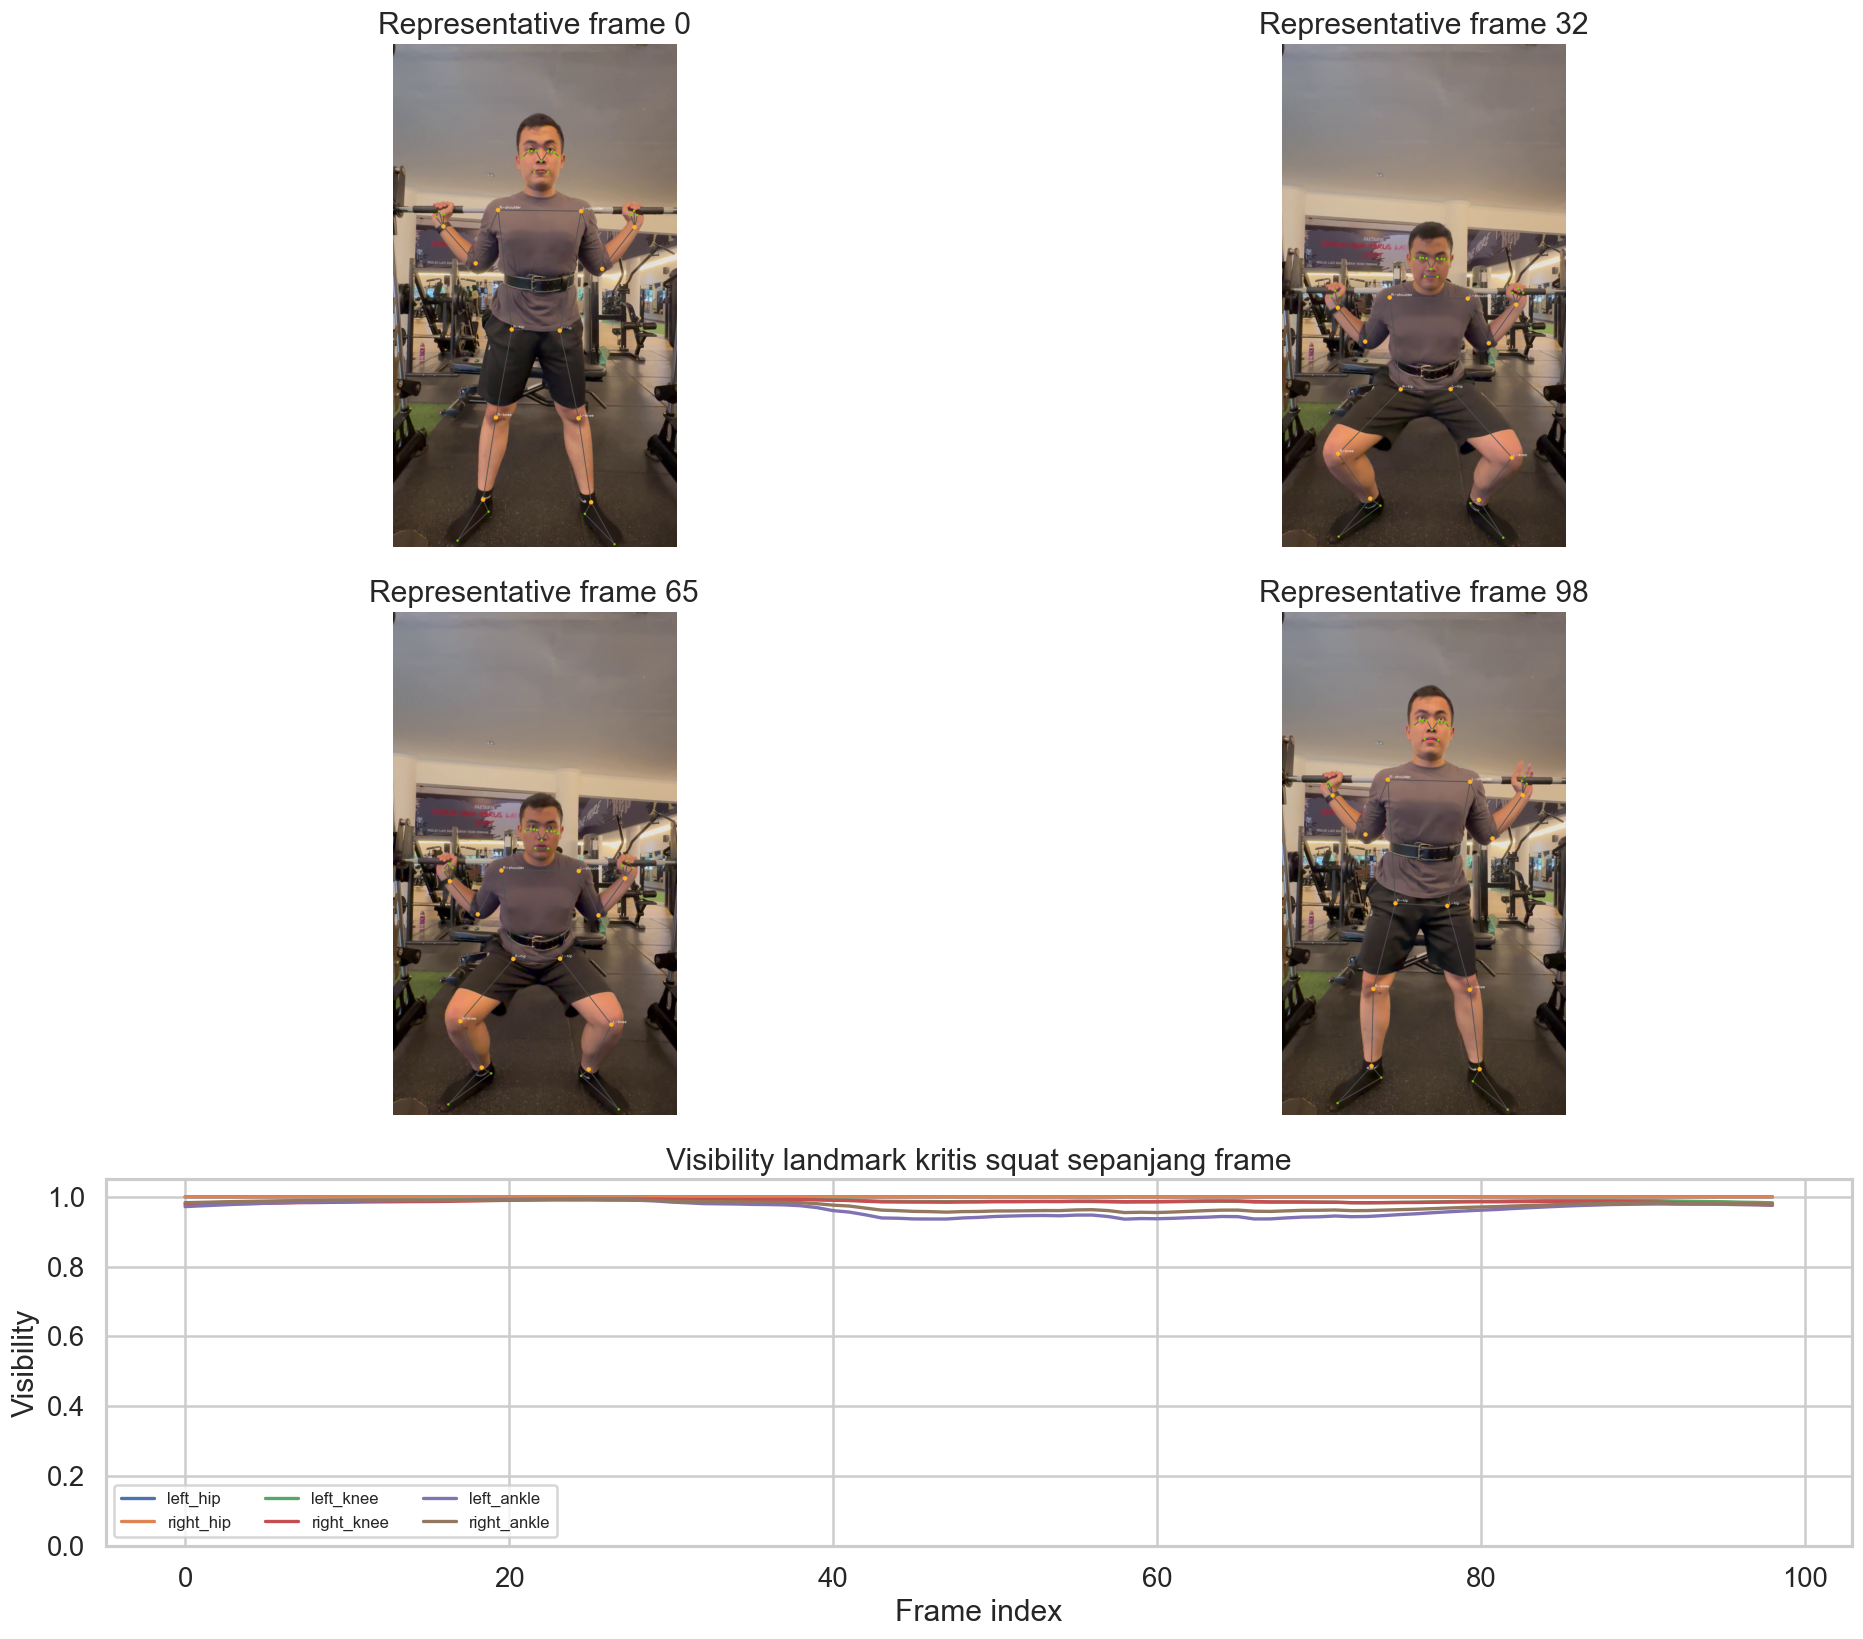

Visual audit MediaPipe disimpan ke: D:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC\results\cvat_pilot_notebook19\point2_mediapipe_visual_audit.png


In [13]:
representative_frames = select_representative_frames(bundle.pose_array.shape[0], count=4)
joint_visibility_over_time = []
for frame_index in range(bundle.pose_array.shape[0]):
    row = {'frame_index': frame_index}
    for joint_name in ['left_hip', 'right_hip', 'left_knee', 'right_knee', 'left_ankle', 'right_ankle']:
        joint_index = CVAT_12_JOINTS.index(joint_name) if joint_name in CVAT_12_JOINTS else None
        mp_index = None
        from analysis.cvat_mediapipe_pilot import LANDMARK_INDEX
        mp_index = LANDMARK_INDEX[joint_name]
        row[joint_name] = float(bundle.pose_array[frame_index, mp_index, 3])
    joint_visibility_over_time.append(row)
joint_visibility_over_time = pd.DataFrame(joint_visibility_over_time)

fig = plt.figure(figsize=(16, 14))
grid = fig.add_gridspec(3, 2, height_ratios=[1.1, 1.1, 0.8])

for plot_index, frame_index in enumerate(representative_frames):
    ax = fig.add_subplot(grid[plot_index // 2, plot_index % 2])
    overlay = draw_pose_overlay(
        bundle.frames_bgr[frame_index],
        bundle.pose_array[frame_index],
        highlight_joint_names=CVAT_12_JOINTS,
        label_joint_names=['left_shoulder', 'right_shoulder', 'left_hip', 'right_hip', 'left_knee', 'right_knee'],
    )
    ax.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    ax.set_title(f'Representative frame {frame_index}')
    ax.axis('off')

ax_bottom = fig.add_subplot(grid[2, :])
for joint_name in ['left_hip', 'right_hip', 'left_knee', 'right_knee', 'left_ankle', 'right_ankle']:
    ax_bottom.plot(joint_visibility_over_time['frame_index'], joint_visibility_over_time[joint_name], linewidth=2, label=joint_name)
ax_bottom.set_title('Visibility landmark kritis squat sepanjang frame')
ax_bottom.set_xlabel('Frame index')
ax_bottom.set_ylabel('Visibility')
ax_bottom.set_ylim(0.0, 1.05)
ax_bottom.legend(ncol=3, fontsize=10)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'point2_mediapipe_visual_audit.png', bbox_inches='tight')
plt.show()
print('Visual audit MediaPipe disimpan ke:', OUTPUT_DIR / 'point2_mediapipe_visual_audit.png')

## Point 2b - Pembanding Eksternal terhadap Skeleton Manual CVAT

Inilah blok yang paling langsung menjawab pertanyaan Pak Jasman: **seberapa baik skeleton MediaPipe dibanding anotasi manual**.

- Jika file ekspor CVAT tersedia di workspace, notebook akan memuatnya dan menghitung galat jarak per-joint.
- Jika file belum ada, notebook tetap menandai dengan jelas bahwa **mekanisme pembanding sudah siap**, tetapi evaluasi manual-vs-MediaPipe belum bisa dihitung pada sesi ini.

Dengan demikian, blok ini membedakan secara tegas antara **audit kualitas internal** dan **validasi eksternal berbasis anotator manusia**.

**CVAT export aktif:** `annotations.xml`

,joint_name,compared_points,mean_error_px,median_error_px,mean_error_norm_torso
0,left_shoulder,1188,648.794967,576.916434,1.425248


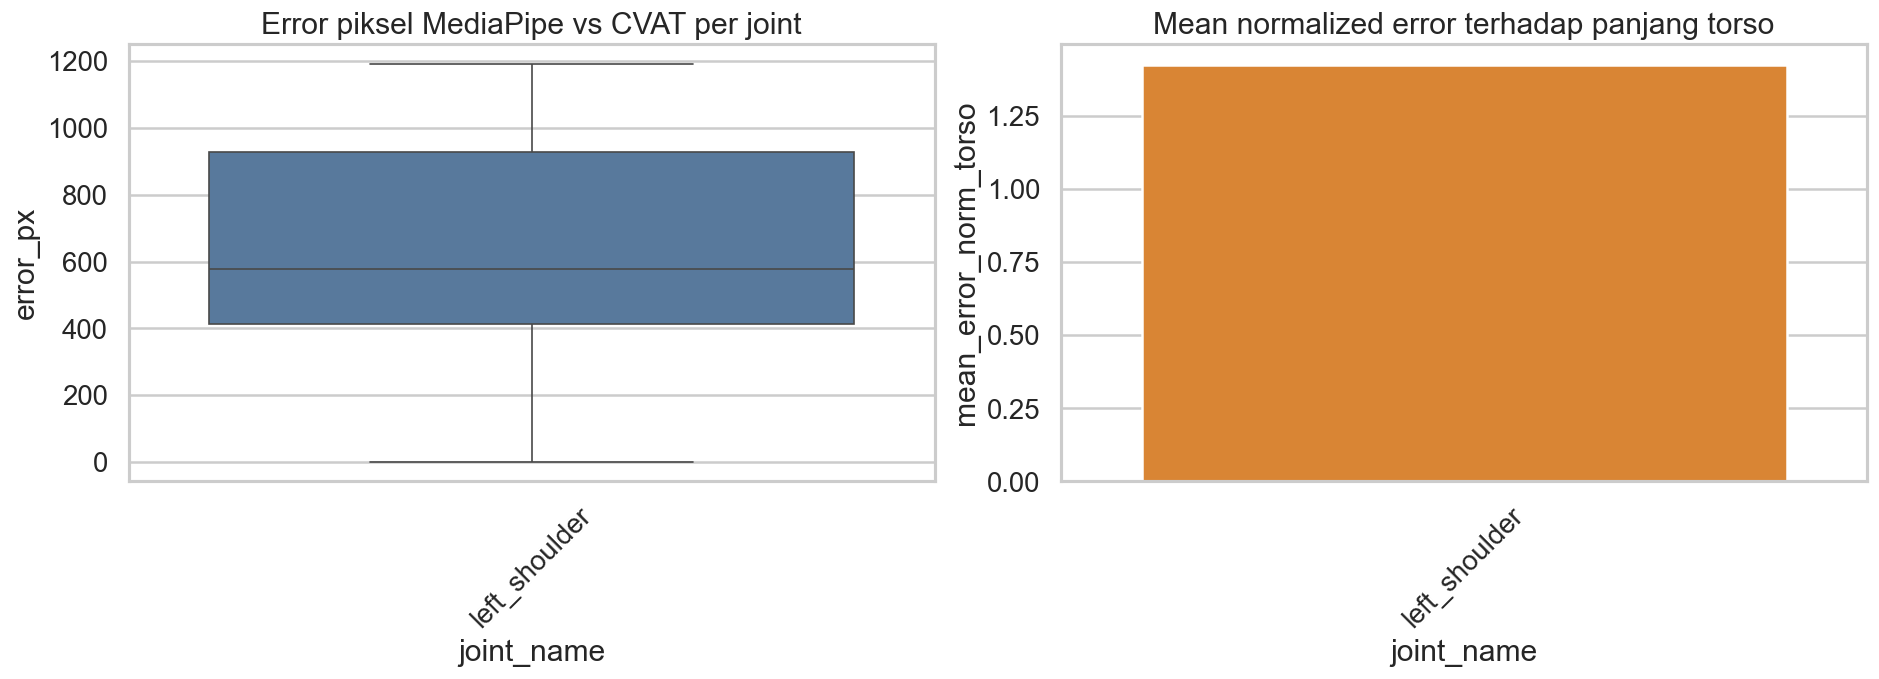

In [18]:
cvat_comparison_df = None
cvat_summary_df = None
cvat_status_message = ''

if CVAT_EXPORT is None:
    searched_paths = [str(path) for path in CVAT_CANDIDATES[:10]]
    cvat_status_message = (
        'Belum ada file ekspor CVAT (.xml/.json) yang terdeteksi di workspace. ' 
        'Blok pembanding manual-vs-MediaPipe sudah siap, tetapi nilai error eksternal belum dapat dihitung pada notebook ini.'
    )
    display(Markdown('**Status CVAT:** ' + cvat_status_message))
else:
    try:
        cvat_df = parse_cvat_skeleton_export(CVAT_EXPORT, joint_names=CVAT_12_JOINTS)
        cvat_comparison_df, cvat_summary_df = compare_cvat_vs_mediapipe(cvat_df, bundle, joint_names=CVAT_12_JOINTS)
        cvat_df.to_csv(OUTPUT_DIR / 'point2b_cvat_points_long.csv', index=False)
        cvat_comparison_df.to_csv(OUTPUT_DIR / 'point2b_cvat_vs_mediapipe_comparison.csv', index=False)
        cvat_summary_df.to_csv(OUTPUT_DIR / 'point2b_cvat_vs_mediapipe_summary.csv', index=False)
        display(Markdown(f'**CVAT export aktif:** `{CVAT_EXPORT.name}`'))
        display(cvat_summary_df)

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        sns.boxplot(data=cvat_comparison_df, x='joint_name', y='error_px', ax=axes[0], color='#4C78A8')
        axes[0].set_title('Error piksel MediaPipe vs CVAT per joint')
        axes[0].tick_params(axis='x', rotation=45)

        sns.barplot(data=cvat_summary_df, x='joint_name', y='mean_error_norm_torso', ax=axes[1], color='#F58518')
        axes[1].set_title('Mean normalized error terhadap panjang torso')
        axes[1].tick_params(axis='x', rotation=45)

        fig.tight_layout()
        fig.savefig(OUTPUT_DIR / 'point2b_cvat_vs_mediapipe.png', bbox_inches='tight')
        plt.show()
    except Exception as exc:
        cvat_status_message = f'File CVAT ditemukan tetapi gagal diparse / dibandingkan: {exc}'
        display(Markdown('**Status CVAT:** ' + cvat_status_message))

## Point 3 - Pelabelan Benar / Salah per-Frame Secara Matematis

Bagian ini mengeksekusi arahan ketiga Pak Jasman. Kuncinya adalah membedakan dua level keputusan:

- **Sequence-level label**: label satu repetisi penuh, seperti yang dipakai AttentiveSkel3D.
- **Frame-level label**: label benar/salah untuk setiap frame berdasarkan aturan biomekanik.

Untuk squat, frame dinyatakan **Benar** hanya jika seluruh syarat berikut terpenuhi pada frame tersebut:

- `valgus_ratio >= 0.85`
- `hip_flexion_angle <= 137 derajat`
- `knee_angle <= 100 derajat`

Secara logika biner, jika salah satu syarat gagal maka frame diberi label **Salah (1)**. Jika semua lolos, frame diberi label **Benar (0)**.

In [15]:
preprocess_bundle = run_preprocess_pipeline(bundle.pose_array, target_frames=64)
normalized_original = preprocess_bundle['normalized']
resampled_tensor = preprocess_bundle['resampled']

validator = BiomechanicalValidator()
sequence_valid, sequence_reason = validator.validate_squat(resampled_tensor)
per_frame_df = PerFrameAnalyzer.analyze_squat_per_frame(normalized_original).copy()
per_frame_df['timestamp_sec'] = per_frame_df['frame_index'] / max(bundle.fps, 1e-6)
per_frame_df['frame_label'] = np.where(per_frame_df['all_criteria_pass'], 0, 1)
per_frame_df['frame_status'] = np.where(per_frame_df['all_criteria_pass'], 'Benar', 'Salah')

summary_point3_df = pd.DataFrame(
    [
        {'Metric': 'Sequence-level validator', 'Value': 'Benar (0)' if sequence_valid else 'Salah (1)'},
        {'Metric': 'Jumlah frame valid', 'Value': int((per_frame_df['frame_label'] == 0).sum())},
        {'Metric': 'Jumlah frame invalid', 'Value': int((per_frame_df['frame_label'] == 1).sum())},
        {'Metric': 'Rasio frame invalid', 'Value': round(float((per_frame_df['frame_label'] == 1).mean()), 4)},
        {'Metric': 'Frame terdalam (knee angle minimum)', 'Value': int(per_frame_df['angle_knee_avg'].idxmin())},
    ]
)

display(summary_point3_df)
display(Markdown('**Reason sequence-level:** ' + sequence_reason))
display(per_frame_df.head(10))

per_frame_df.to_csv(OUTPUT_DIR / 'point3_frame_labels.csv', index=False)
summary_point3_df.to_csv(OUTPUT_DIR / 'point3_summary.csv', index=False)
np.save(OUTPUT_DIR / 'point3_resampled_tensor_64x33x3.npy', resampled_tensor)
print('Frame labels disimpan ke:', OUTPUT_DIR / 'point3_frame_labels.csv')

,Metric,Value
0,Sequence-level validator,Benar (0)
1,Jumlah frame valid,85
2,Jumlah frame invalid,14
3,Rasio frame invalid,0.1414
4,Frame terdalam (knee angle minimum),53


**Reason sequence-level:** Squat valid. Kedalaman pinggul (36.0°) dan posisi lutut sempurna. Otot Gluteal dan Quadriceps bekerja maksimal. (Sudut lutut min = 23.3°, rasio lutut/kaki = 1.50, frame terdalam = 34.)

,frame_index,angle_knee_left,angle_knee_right,angle_knee_avg,angle_hip_left,angle_hip_right,angle_hip_avg,valgus_ratio,criteria_1_pass,criteria_2_pass,criteria_3_pass,all_criteria_pass,landmarks,timestamp_sec,frame_label,frame_status
0,0,117.20,116.24,116.72,139.94,151.16,145.55,0.7641,False,False,False,False,"L/R Shoulder, Hip, Knee, Ankle",0.000000,1,Salah
1,1,111.53,98.74,105.13,142.15,145.92,144.03,0.7641,False,False,False,False,"L/R Shoulder, Hip, Knee, Ankle",0.033333,1,Salah
2,2,112.74,98.51,105.62,141.19,139.44,140.32,0.7653,False,False,False,False,"L/R Shoulder, Hip, Knee, Ankle",0.066667,1,Salah
3,3,112.14,97.14,104.64,137.39,133.61,135.50,0.7683,False,True,False,False,"L/R Shoulder, Hip, Knee, Ankle",0.100000,1,Salah
4,4,110.43,97.24,103.83,136.04,133.75,134.89,0.7764,False,True,False,False,"L/R Shoulder, Hip, Knee, Ankle",0.133333,1,Salah
5,5,105.41,91.49,98.45,131.71,129.60,130.66,0.7989,False,True,True,False,"L/R Shoulder, Hip, Knee, Ankle",0.166667,1,Salah
6,6,102.63,85.09,93.86,126.02,119.18,122.60,0.8354,False,True,True,False,"L/R Shoulder, Hip, Knee, Ankle",0.200000,1,Salah
7,7,99.71,78.61,89.16,119.43,106.87,113.15,0.8671,True,True,True,True,"L/R Shoulder, Hip, Knee, Ankle",0.233333,0,Benar
8,8,95.27,72.98,84.12,115.51,101.45,108.48,0.9115,True,True,True,True,"L/R Shoulder, Hip, Knee, Ankle",0.266667,0,Benar
9,9,91.65,66.97,79.31,113.55,96.87,105.21,0.9505,True,True,True,True,"L/R Shoulder, Hip, Knee, Ankle",0.300000,0,Benar


Frame labels disimpan ke: D:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC\results\cvat_pilot_notebook19\point3_frame_labels.csv


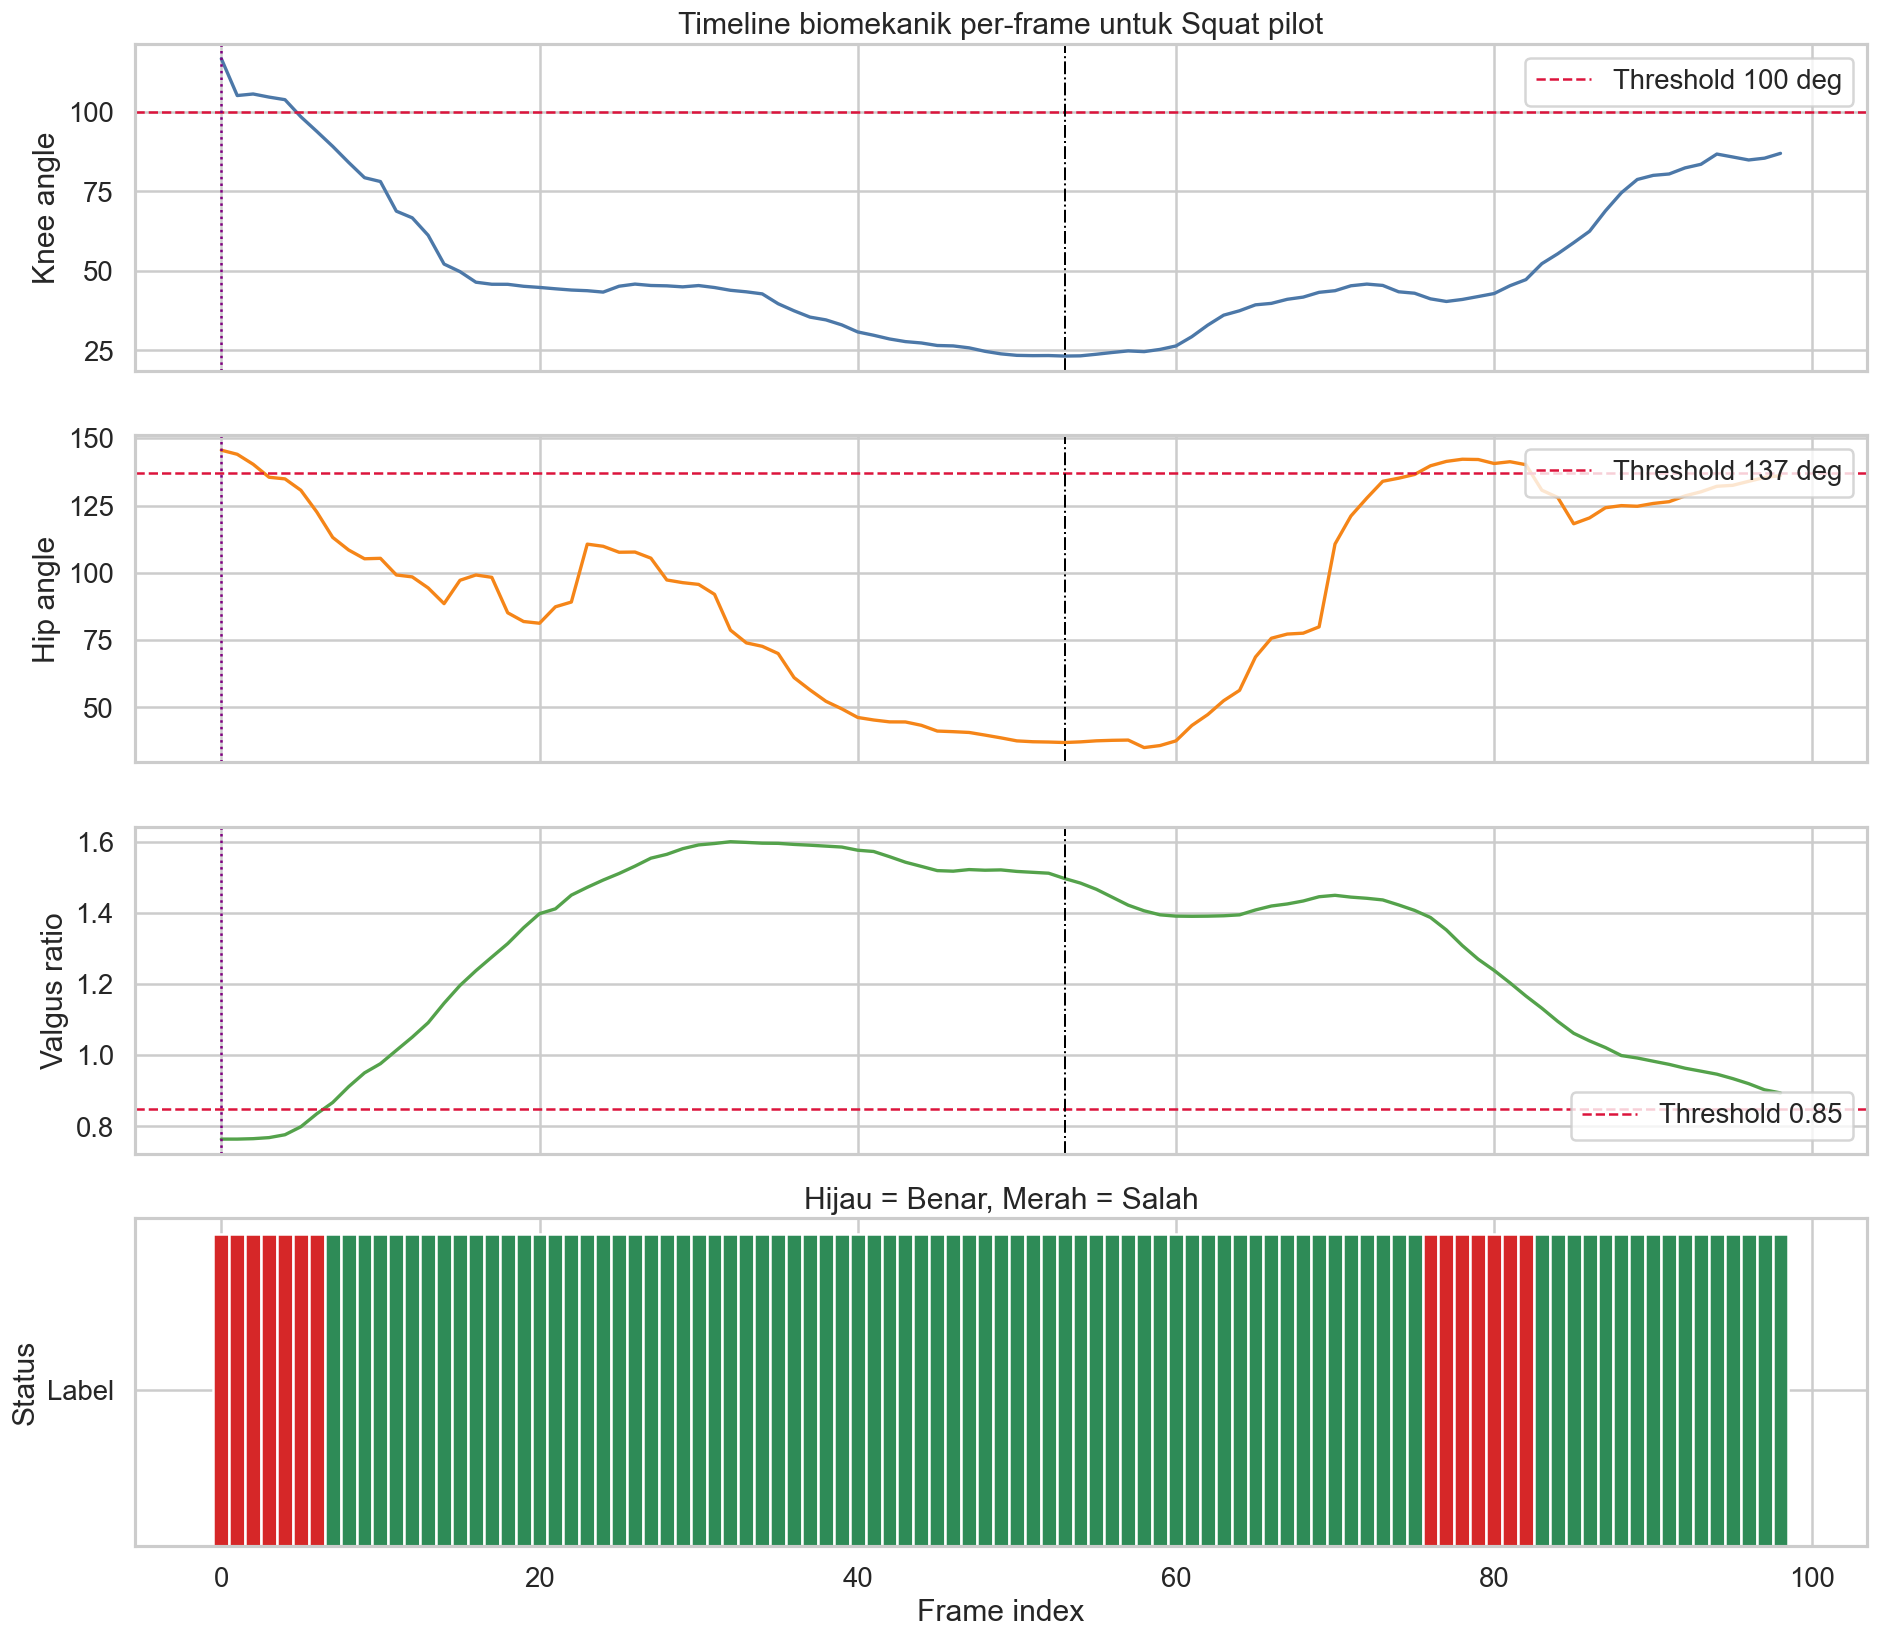

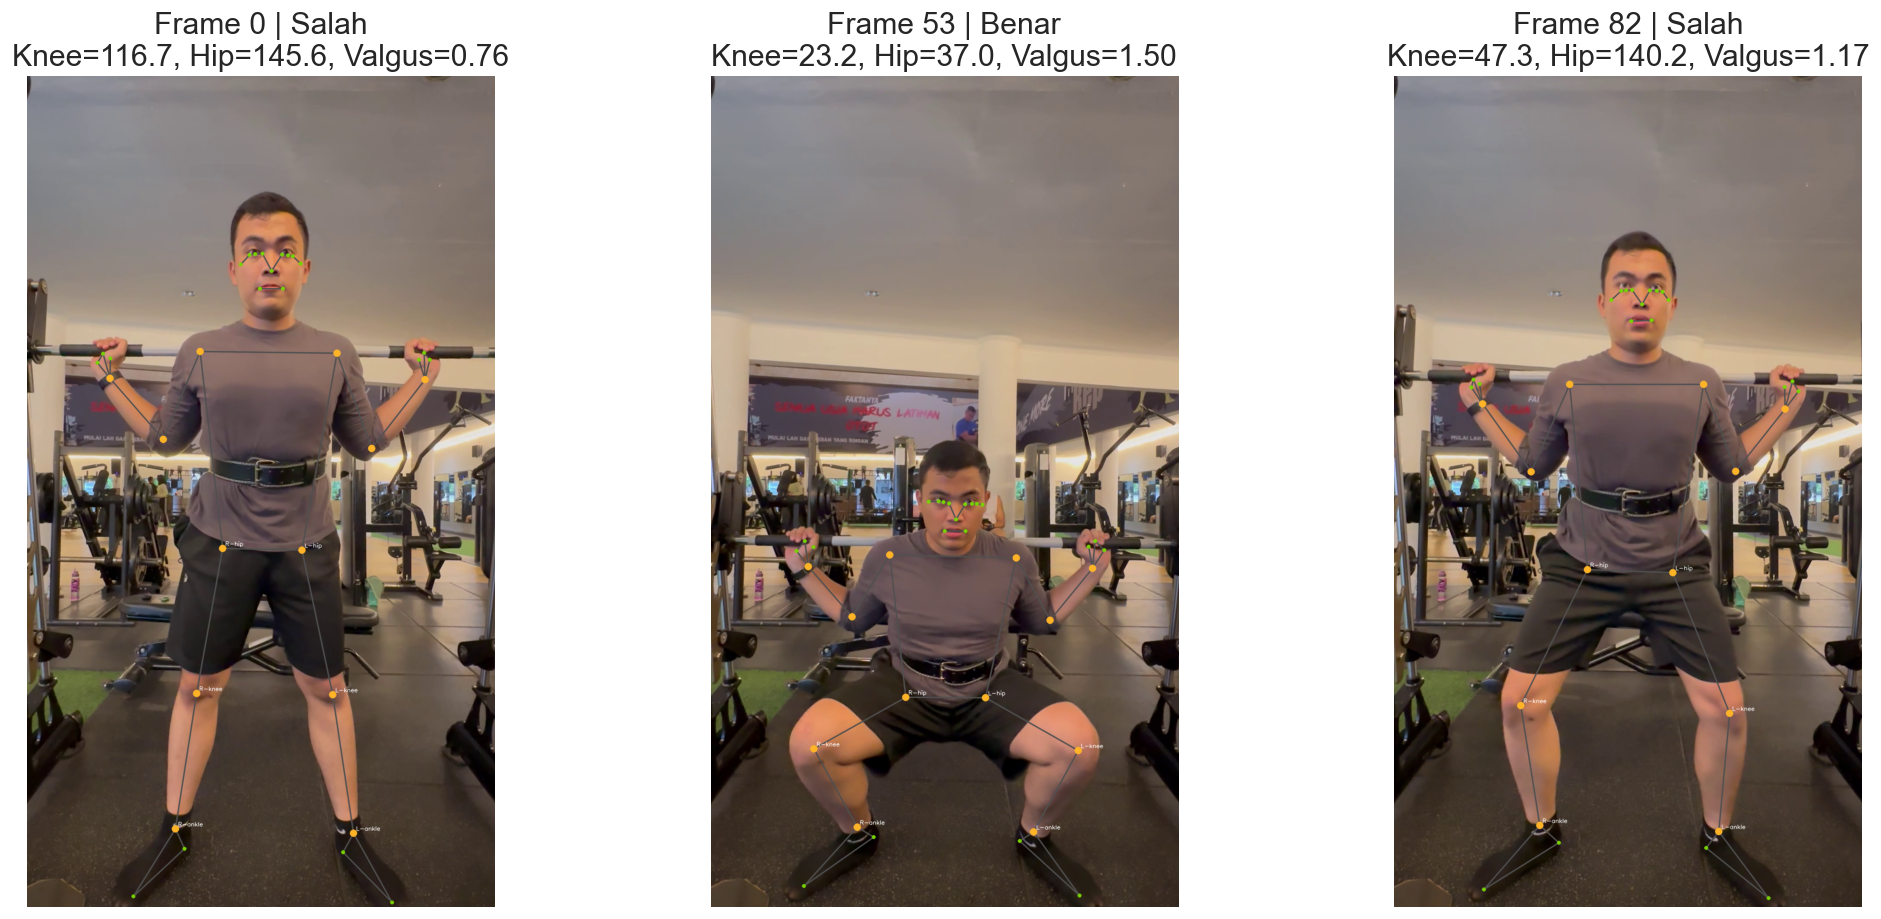

Timeline disimpan ke      : D:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC\results\cvat_pilot_notebook19\point3_frame_label_timeline.png
Critical frames disimpan : D:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC\results\cvat_pilot_notebook19\point3_critical_frames.png


In [16]:
first_invalid = int(per_frame_df.loc[per_frame_df['frame_label'].eq(1), 'frame_index'].min()) if (per_frame_df['frame_label'] == 1).any() else None
last_invalid = int(per_frame_df.loc[per_frame_df['frame_label'].eq(1), 'frame_index'].max()) if (per_frame_df['frame_label'] == 1).any() else None
deepest_frame = int(per_frame_df['angle_knee_avg'].idxmin())

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)
frame_axis = per_frame_df['frame_index']

axes[0].plot(frame_axis, per_frame_df['angle_knee_avg'], color='#4C78A8', linewidth=2)
axes[0].axhline(100.0, color='crimson', linestyle='--', linewidth=1.5, label='Threshold 100 deg')
axes[0].set_ylabel('Knee angle')
axes[0].set_title('Timeline biomekanik per-frame untuk Squat pilot')
axes[0].legend(loc='upper right')

axes[1].plot(frame_axis, per_frame_df['angle_hip_avg'], color='#F58518', linewidth=2)
axes[1].axhline(137.0, color='crimson', linestyle='--', linewidth=1.5, label='Threshold 137 deg')
axes[1].set_ylabel('Hip angle')
axes[1].legend(loc='upper right')

axes[2].plot(frame_axis, per_frame_df['valgus_ratio'], color='#54A24B', linewidth=2)
axes[2].axhline(0.85, color='crimson', linestyle='--', linewidth=1.5, label='Threshold 0.85')
axes[2].set_ylabel('Valgus ratio')
axes[2].legend(loc='lower right')

status_colors = per_frame_df['frame_label'].map({0: '#2E8B57', 1: '#D62728'})
axes[3].bar(frame_axis, np.ones(len(per_frame_df)), color=status_colors, width=1.0)
axes[3].set_ylabel('Status')
axes[3].set_xlabel('Frame index')
axes[3].set_yticks([0.5])
axes[3].set_yticklabels(['Label'])
axes[3].set_title('Hijau = Benar, Merah = Salah')

for ax in axes[:3]:
    if first_invalid is not None:
        ax.axvline(first_invalid, color='purple', linestyle=':', linewidth=1.5, label='First invalid')
    ax.axvline(deepest_frame, color='black', linestyle='-.', linewidth=1.2, label='Deepest frame')

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'point3_frame_label_timeline.png', bbox_inches='tight')
plt.show()

focus_frames = [idx for idx in [first_invalid, deepest_frame, last_invalid] if idx is not None]
focus_frames = list(dict.fromkeys(focus_frames))
if focus_frames:
    fig, axes = plt.subplots(1, len(focus_frames), figsize=(6 * len(focus_frames), 8))
    if len(focus_frames) == 1:
        axes = [axes]

    for ax, frame_index in zip(axes, focus_frames):
        overlay = draw_pose_overlay(
            bundle.frames_bgr[frame_index],
            bundle.pose_array[frame_index],
            highlight_joint_names=CVAT_12_JOINTS,
            label_joint_names=['left_hip', 'right_hip', 'left_knee', 'right_knee', 'left_ankle', 'right_ankle'],
        )
        row = per_frame_df.loc[per_frame_df['frame_index'] == frame_index].iloc[0]
        title_text = (
            f"Frame {frame_index} | {row.frame_status}\n"
            f"Knee={row.angle_knee_avg:.1f}, Hip={row.angle_hip_avg:.1f}, Valgus={row.valgus_ratio:.2f}"
        )
        ax.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
        ax.set_title(title_text)
        ax.axis('off')

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / 'point3_critical_frames.png', bbox_inches='tight')
    plt.show()

print('Timeline disimpan ke      :', OUTPUT_DIR / 'point3_frame_label_timeline.png')
print('Critical frames disimpan :', OUTPUT_DIR / 'point3_critical_frames.png')

In [17]:
cvat_line = (
    '- Pembanding eksternal CVAT berhasil dijalankan dan menghasilkan galat per-joint yang dapat dipakai sebagai ukuran objektif kualitas skeleton MediaPipe.'
    if cvat_summary_df is not None
    else '- Pembanding eksternal CVAT belum bisa dihitung pada sesi ini karena file ekspor anotasi belum tersedia atau belum cocok formatnya, tetapi pipeline pembandingnya sudah siap.'
)

report_md = f'''
## Kesimpulan yang Siap Disampaikan ke Pak Jasman

1. **Poin 1 terjawab:** untuk pilot anotasi manual squat, skema yang paling masuk akal adalah **12 joint utama** sebagai anotasi CVAT, dengan **8 joint inti** sebagai subset minimum yang benar-benar dipakai validator biomekanik.
2. **Poin 2 terjawab:** titik sendi MediaPipe memang berhasil dikeluarkan. Pada video pilot ini terdeteksi **{int(bundle.detected_mask.sum())} dari {int(bundle.pose_array.shape[0])} frame** dengan pose, dan visibility rata-rata 12 joint utama berada di **{visibility_df['mean_visibility'].mean():.4f}**.
3. {cvat_line}
4. **Poin 3 terjawab:** label benar/salah per-frame dapat dibentuk secara matematis dari tiga aturan squat. Pada video pilot ini terdapat **{int((per_frame_df['frame_label'] == 1).sum())} frame Salah** dan **{int((per_frame_df['frame_label'] == 0).sum())} frame Benar**.
5. **Hubungan dengan `web_app/app.py`:** benar bahwa fondasi frame-level labeling sudah ada di dashboard, tetapi notebook ini menambahkan bentuk audit yang lebih presentable untuk pembimbing: tabel joint, data ekspor, timeline threshold, dan visual critical frames.

### Artefak utama yang dihasilkan notebook ini
- `results/cvat_pilot_notebook19/point2_mediapipe_visual_audit.png`
- `results/cvat_pilot_notebook19/point3_frame_label_timeline.png`
- `results/cvat_pilot_notebook19/point3_critical_frames.png`
- `results/cvat_pilot_notebook19/point3_frame_labels.csv`

Dengan kata lain, notebook ini dapat dipakai sebagai **jawaban teknis dan visual** atas tiga permintaan Pak Jasman, sekaligus menjadi template untuk memperluas evaluasi ke sampel video lain.
'''
display(Markdown(report_md))


## Kesimpulan yang Siap Disampaikan ke Pak Jasman

1. **Poin 1 terjawab:** untuk pilot anotasi manual squat, skema yang paling masuk akal adalah **12 joint utama** sebagai anotasi CVAT, dengan **8 joint inti** sebagai subset minimum yang benar-benar dipakai validator biomekanik.
2. **Poin 2 terjawab:** titik sendi MediaPipe memang berhasil dikeluarkan. Pada video pilot ini terdeteksi **99 dari 99 frame** dengan pose, dan visibility rata-rata 12 joint utama berada di **0.9751**.
3. - Pembanding eksternal CVAT berhasil dijalankan dan menghasilkan galat per-joint yang dapat dipakai sebagai ukuran objektif kualitas skeleton MediaPipe.
4. **Poin 3 terjawab:** label benar/salah per-frame dapat dibentuk secara matematis dari tiga aturan squat. Pada video pilot ini terdapat **14 frame Salah** dan **85 frame Benar**.
5. **Hubungan dengan `web_app/app.py`:** benar bahwa fondasi frame-level labeling sudah ada di dashboard, tetapi notebook ini menambahkan bentuk audit yang lebih presentable untuk pembimbing: tabel joint, data ekspor, timeline threshold, dan visual critical frames.

### Artefak utama yang dihasilkan notebook ini
- `results/cvat_pilot_notebook19/point2_mediapipe_visual_audit.png`
- `results/cvat_pilot_notebook19/point3_frame_label_timeline.png`
- `results/cvat_pilot_notebook19/point3_critical_frames.png`
- `results/cvat_pilot_notebook19/point3_frame_labels.csv`

Dengan kata lain, notebook ini dapat dipakai sebagai **jawaban teknis dan visual** atas tiga permintaan Pak Jasman, sekaligus menjadi template untuk memperluas evaluasi ke sampel video lain.
